Importer les données à l’aide de pandas.

In [1]:
import pandas as pd
import numpy as np


df = pd.read_csv("../data/raw/dataset-diabete.csv")



Comprendre la structure générale du jeu de données (types, dimensions, aperçus).

In [2]:
print(f"database shape : {df.shape[0]} lignes and {df.shape[1]} column \n")

display(df.head())

print(f"\n \ninfos for our dataset : \n ")
df.info()

database shape : 768 lignes and 9 column 



,ID,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,0,6,148,72,35,0,33.6,0.627,50
1,1,1,85,66,29,0,26.6,0.351,31
2,2,8,183,64,0,0,23.3,0.672,32
3,3,1,89,66,23,94,28.1,0.167,21
4,4,0,137,40,35,168,43.1,2.288,33



 
infos for our dataset : 
 
<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ID                        768 non-null    int64  
 1   Pregnancies               768 non-null    int64  
 2   Glucose                   768 non-null    int64  
 3   BloodPressure             768 non-null    int64  
 4   SkinThickness             768 non-null    int64  
 5   Insulin                   768 non-null    int64  
 6   BMI                       768 non-null    float64
 7   DiabetesPedigreeFunction  768 non-null    float64
 8   Age                       768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


Identifier les valeurs manquantes et les doublons.

In [3]:
print("values nan : ")

display(df.isnull().sum())

doublons = df.duplicated().sum()

display(doublons)

if doublons > 0:
    df = df.drop_duplicates()
    print('we droped the duplicated values by succesfully')


values nan : 


ID                          0
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
dtype: int64

np.int64(0)

Analyser la distribution des variables numériques.

,ID,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,383.500000,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885
std,221.846794,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000
25%,191.750000,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000
50%,383.500000,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000
75%,575.250000,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000
max,767.000000,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000


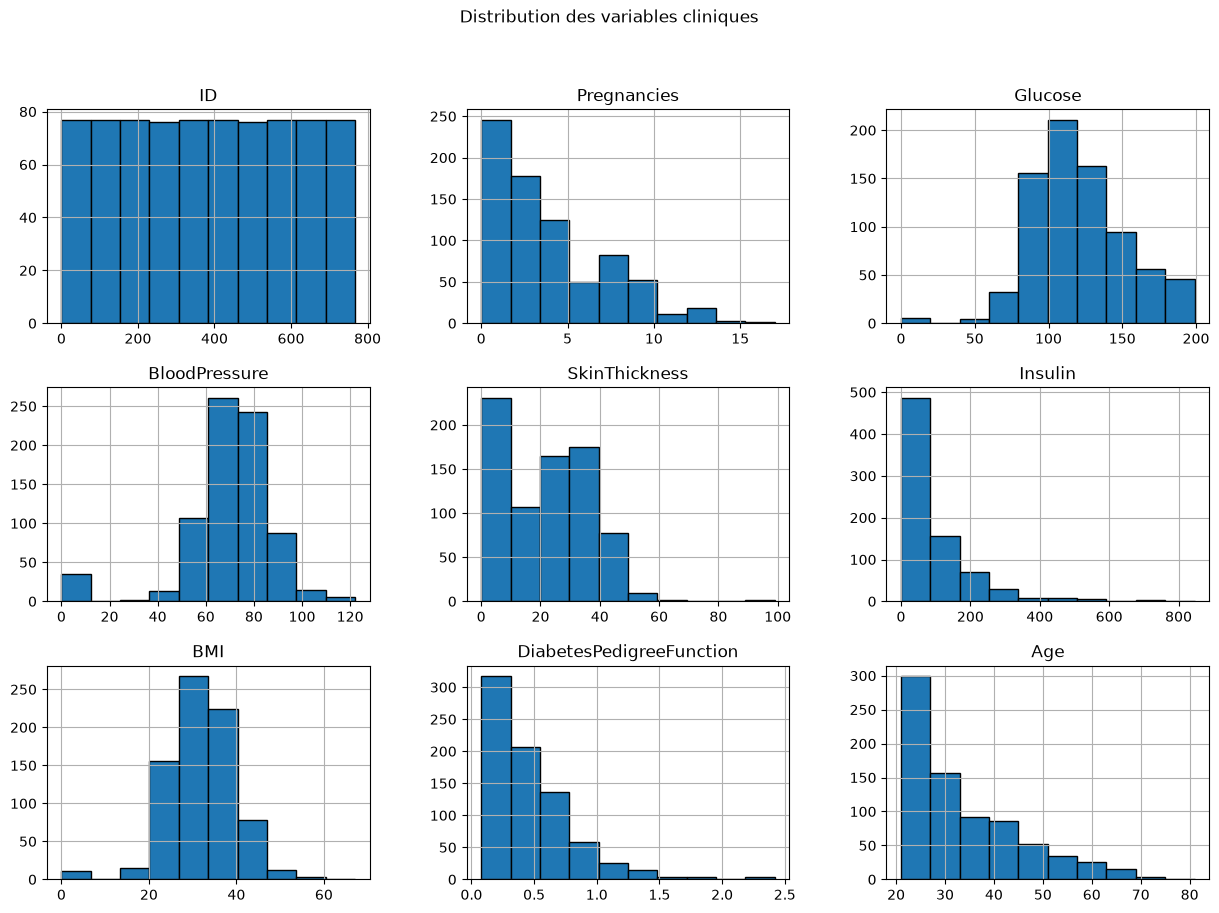

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

display(df.describe())

df.hist(figsize=(15, 10),edgecolor='black')

plt.suptitle('Distribution des variables cliniques')

plt.show()


## Étape 2 — Prétraitement des données - Gestion des valeurs manquantes et aberrantes

Identifier et traiter les valeurs manquantes dans le jeu de données si elles existent.

In [5]:
from sklearn.impute import KNNImputer

df = df.drop('ID', axis=1)

imputer = KNNImputer(n_neighbors=5)

cols_with_zeros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df[cols_with_zeros] = df[cols_with_zeros].replace(0, np.nan)

df_imputed = pd.DataFrame(imputer.fit_transform(df), columns=df.columns)


print(df_imputed.isnull().sum())

display(df_imputed)

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
dtype: int64


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6.0,148.0,72.0,35.0,169.0,33.6,0.627,50.0
1,1.0,85.0,66.0,29.0,58.6,26.6,0.351,31.0
2,8.0,183.0,64.0,25.8,164.6,23.3,0.672,32.0
3,1.0,89.0,66.0,23.0,94.0,28.1,0.167,21.0
4,0.0,137.0,40.0,35.0,168.0,43.1,2.288,33.0
...,...,...,...,...,...,...,...,...
763,10.0,101.0,76.0,48.0,180.0,32.9,0.171,63.0
764,2.0,122.0,70.0,27.0,165.0,36.8,0.340,27.0
765,5.0,121.0,72.0,23.0,112.0,26.2,0.245,30.0
766,1.0,126.0,60.0,35.2,134.2,30.1,0.349,47.0


Utiliser des techniques statistiques (ex. : boîte à moustaches, z-score, IQR) pour détecter les outliers.
Gérer les lignes contenant des valeurs aberrantes dans les colonnes pertinentes.

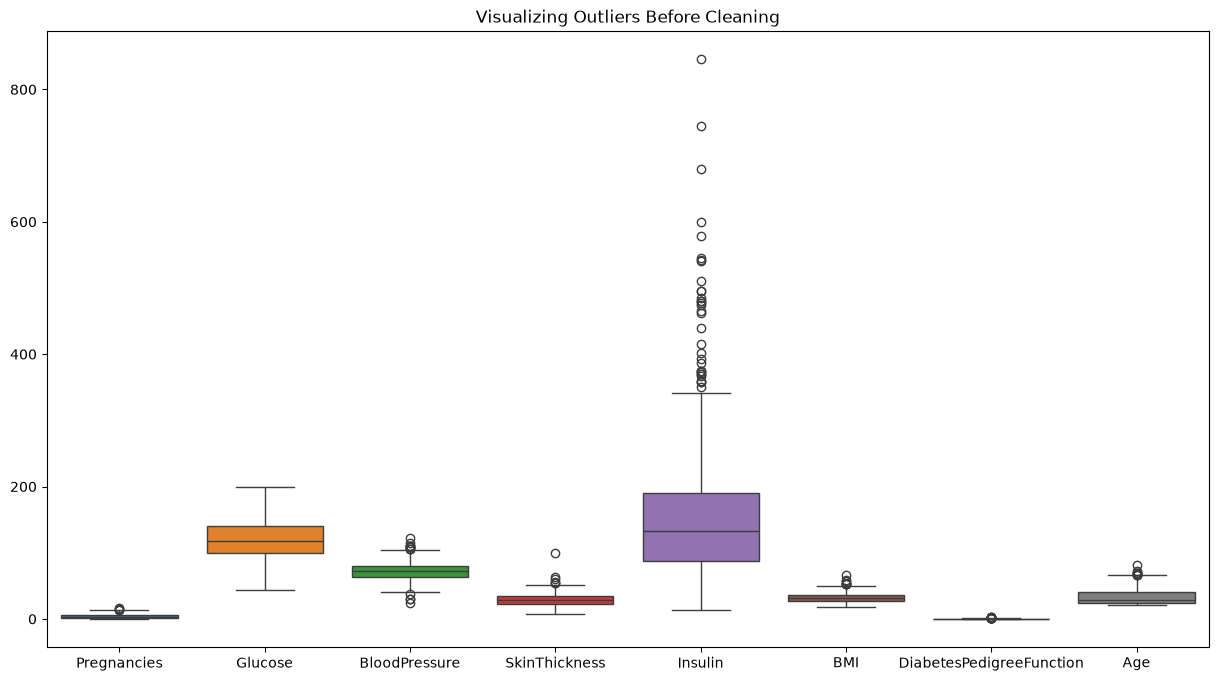

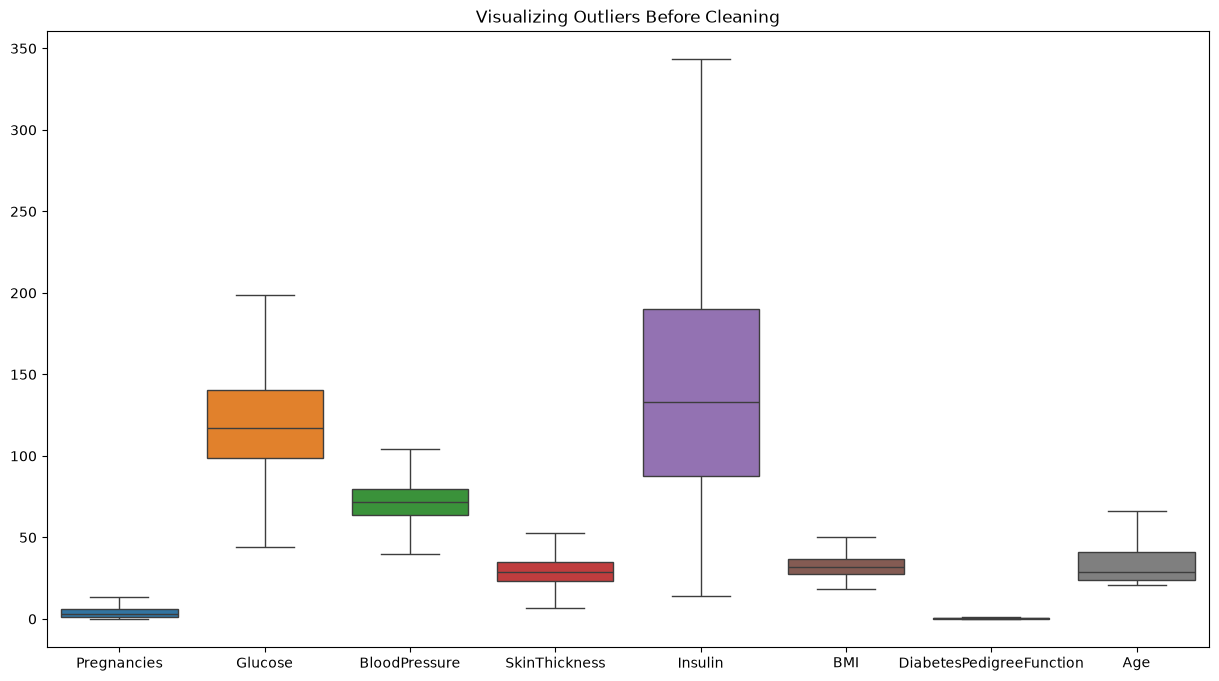

In [6]:


plt.figure(figsize=(15, 8))
sns.boxplot(data=df_imputed) 
plt.title("Visualizing Outliers Before Cleaning")
plt.show()

Q1 = df_imputed.quantile(0.25)
Q3 = df_imputed.quantile(0.75)
IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

df_cleaned = df_imputed.clip(lower=lower_limit, upper=upper_limit, axis=1)

plt.figure(figsize=(15, 8))
sns.boxplot(data=df_cleaned) 
plt.title("Visualizing Outliers Before Cleaning")
plt.show()


Étudier les relations entre les variables.

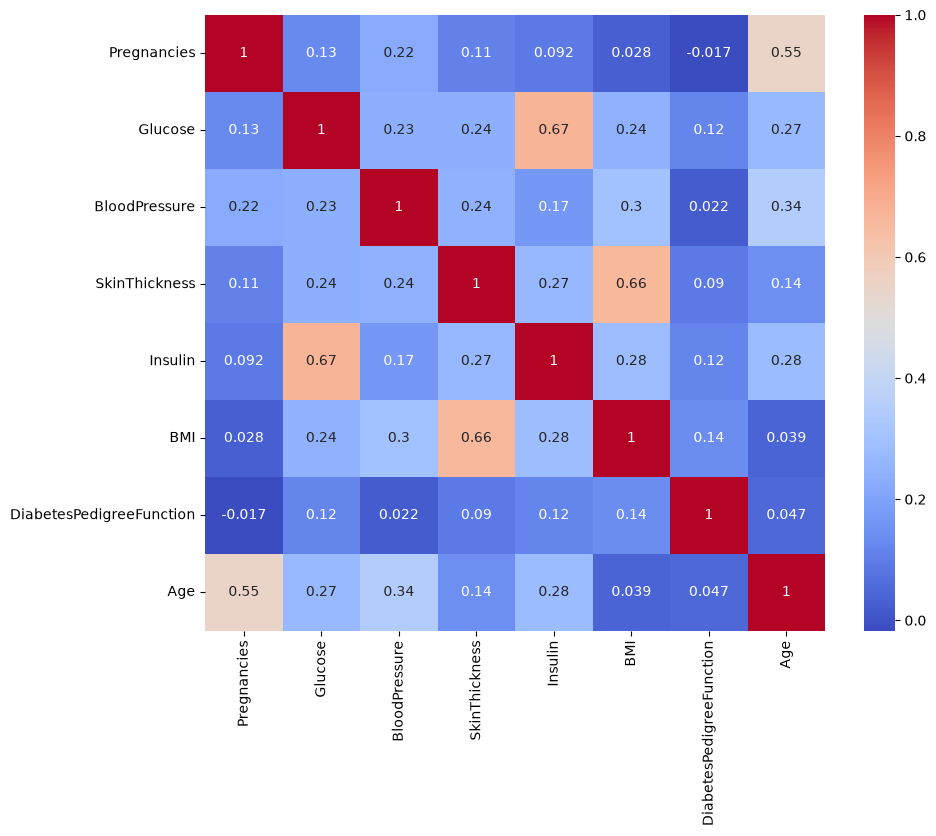

In [7]:
corr_matrix = df_cleaned.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix,annot=True,cmap='coolwarm')
plt.show()

Sélectionner les variables présentant la plus grande variabilité.

In [8]:
variances = df_cleaned.var().sort_values(ascending=False)
display(variances)


df_cleaned['Insulin_Glucose_Ratio'] = df_cleaned['Insulin'] / df_cleaned['Glucose']


df_cleaned['BMI-Category'] = df_cleaned['BMI'].apply(lambda x: 1 if 18.5 <= x < 25 else (2 if 25 <= x < 30 else 3))



Insulin                     6222.973505
Glucose                      930.039162
BloodPressure                139.500526
Age                          135.219778
SkinThickness                 81.580191
BMI                           44.598584
Pregnancies                   11.183383
DiabetesPedigreeFunction       0.081565
dtype: float64

Visualiser les relations entre les variables via des outils graphiques comme le pairplot.

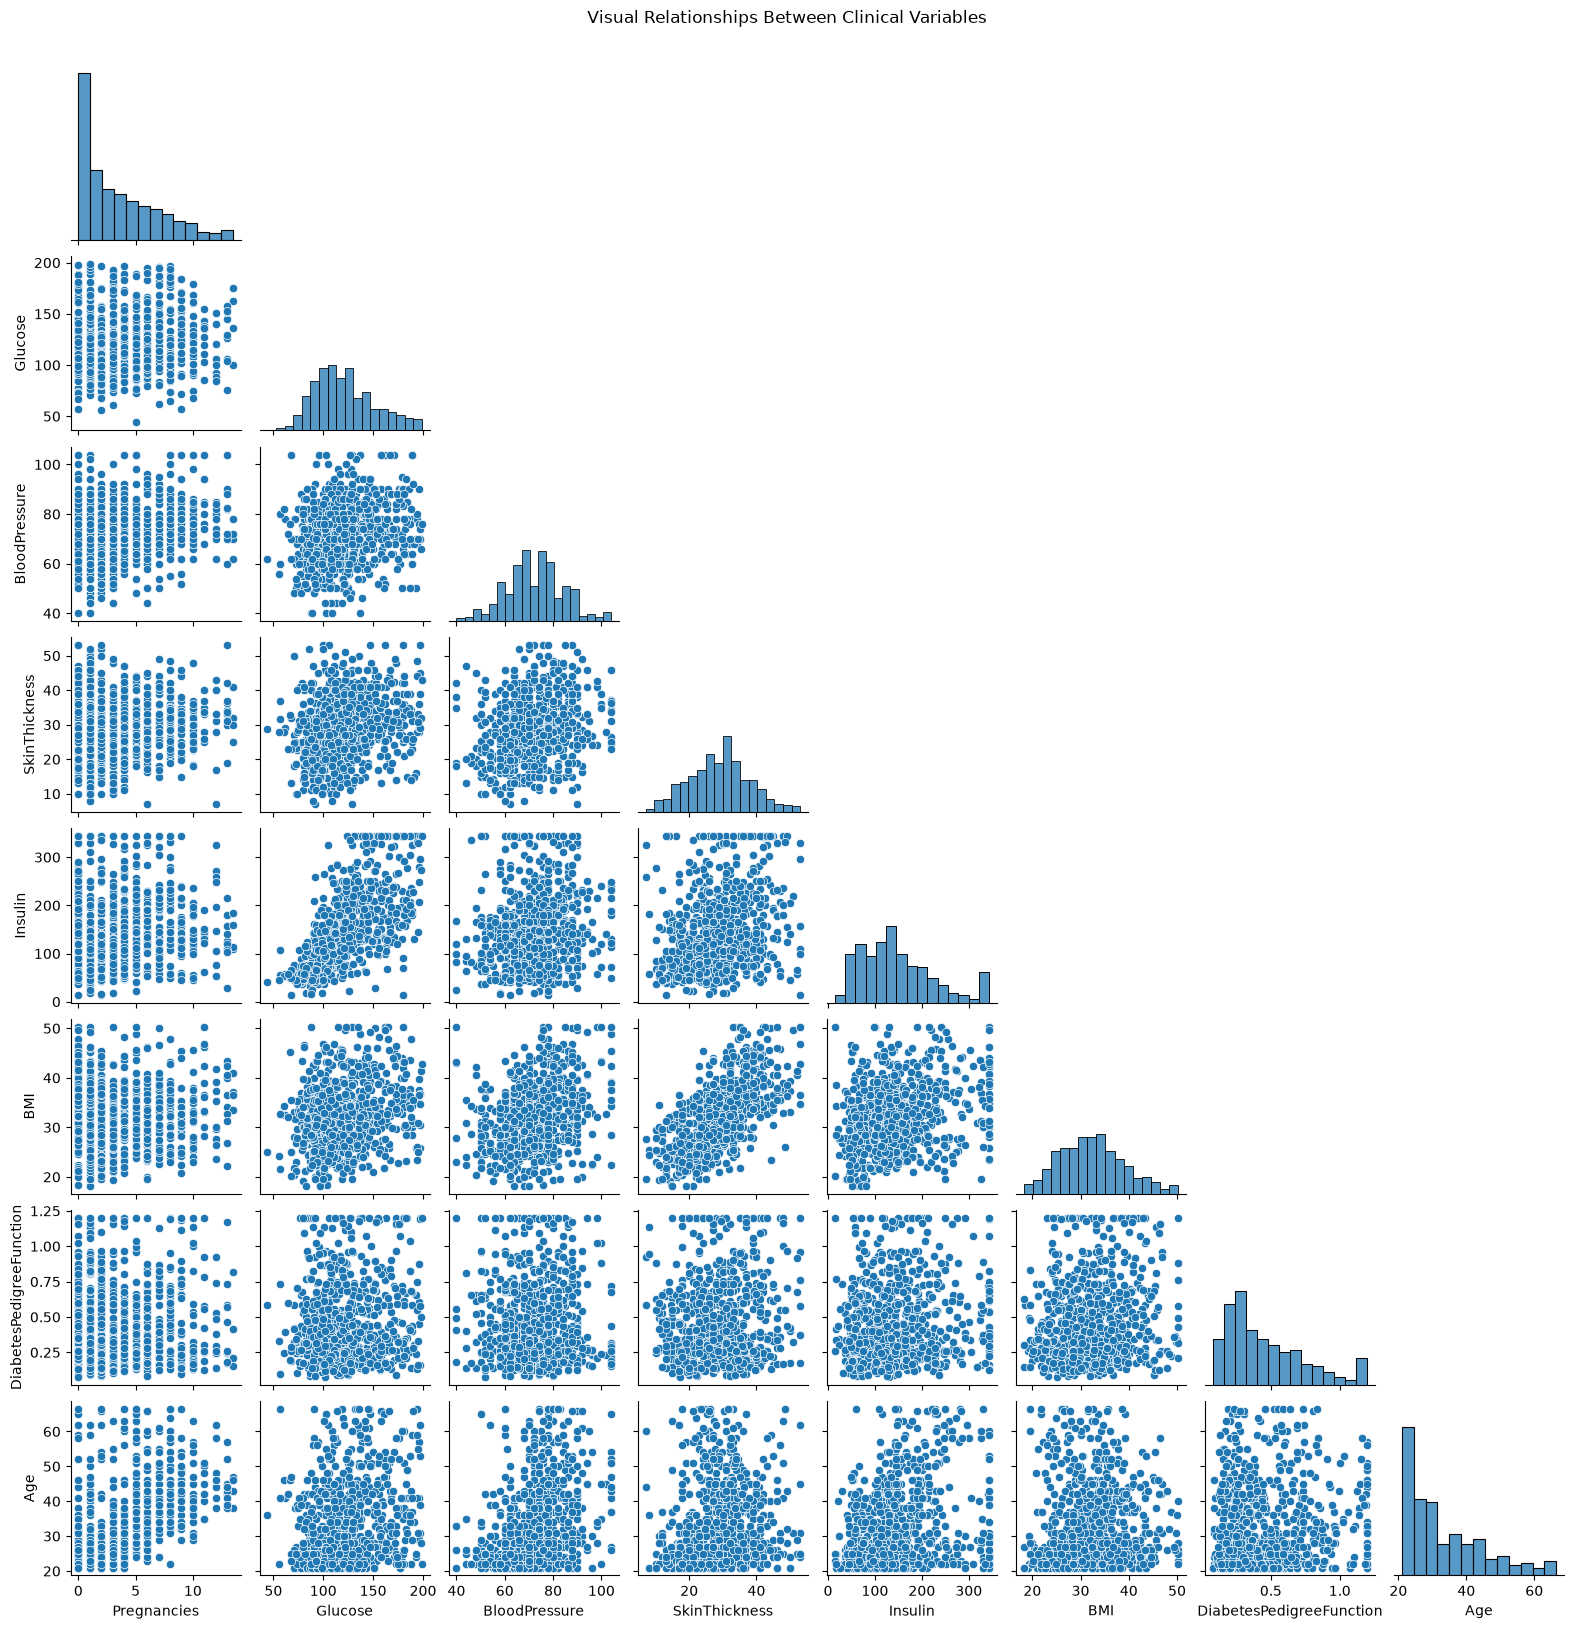

In [9]:
df_analysis = df_cleaned.copy()
df_analysis = df_analysis.drop(['BMI-Category', 'Insulin_Glucose_Ratio'], axis=1)

sns.pairplot(df_analysis, height=2, corner=True)
plt.suptitle('Visual Relationships Between Clinical Variables', y=1.02)
plt.show()

Appliquer la technique appropriée pour normaliser ou standardiser les échelles des variables numériques.

In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_data = scaler.fit_transform(df_cleaned)
df_scaled = pd.DataFrame(scaled_data, columns=df_cleaned.columns)

display(df_scaled)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Insulin_Glucose_Ratio,BMI-Category
0,0.647150,0.866296,-0.030050,0.662965,0.272493,0.185339,0.588927,1.445691,-0.070595,0.705406
1,-0.848970,-1.200858,-0.538380,-0.001760,-1.127910,-0.863528,-0.378101,-0.189304,-1.004756,-0.687272
2,1.245598,2.014715,-0.707824,-0.356280,0.216680,-1.357994,0.746595,-0.103252,-0.571118,-2.079951
3,-0.848970,-1.069610,-0.538380,-0.666485,-0.678867,-0.638771,-1.022787,-1.049828,-0.247551,-0.687272
4,-1.148194,0.505364,-2.741146,0.662965,0.259809,1.608801,2.596563,-0.017199,0.103622,0.705406
...,...,...,...,...,...,...,...,...,...,...
763,1.844045,-0.675867,0.308837,2.103202,0.412026,0.080452,-1.008772,2.564372,1.251298,0.705406
764,-0.549746,0.013185,-0.199493,-0.223335,0.221754,0.664821,-0.416642,-0.533513,0.364128,0.705406
765,0.347926,-0.019627,-0.030050,-0.666485,-0.450541,-0.923463,-0.749497,-0.275356,-0.517096,-0.687272
766,-0.848970,0.144432,-1.046711,0.685122,-0.168938,-0.339095,-0.385109,1.187534,-0.229177,0.705406


## Étape 3 — Entraînement des modèles de clustering avec K-Means

Déterminer la valeur optimale de k via la méthode du coude et silhouette.

In [11]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

silhouette_scores = []
inertia = []

k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(df_scaled)
    labels = kmeans.labels_
    score = silhouette_score(df_scaled, labels)
    silhouette_scores.append(score)
    inertia.append(kmeans.inertia_)
    
best_index = silhouette_scores.index(max(silhouette_scores))

best_k = k_range[best_index]

print(f"The best number of clusters is {best_k}!")



The best number of clusters is 2!


Visualiser la courbe d’inertie et silhouette pour appuyer le choix de k.

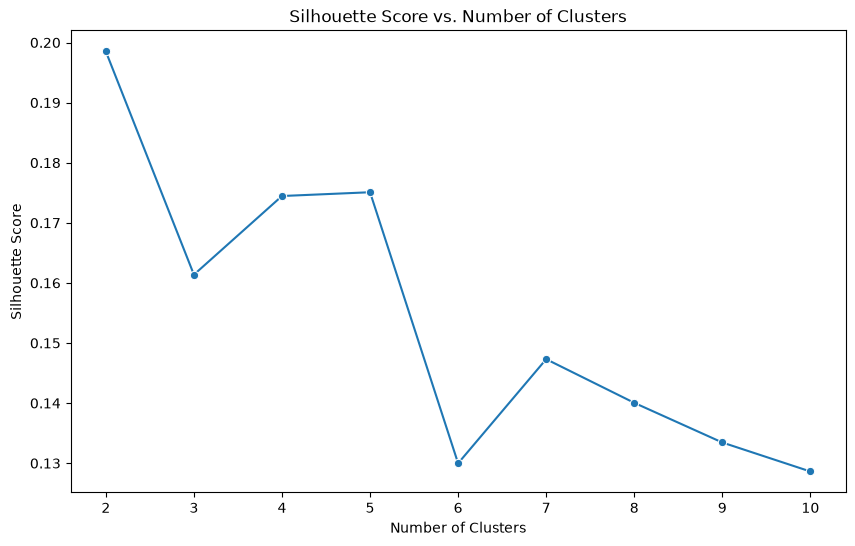

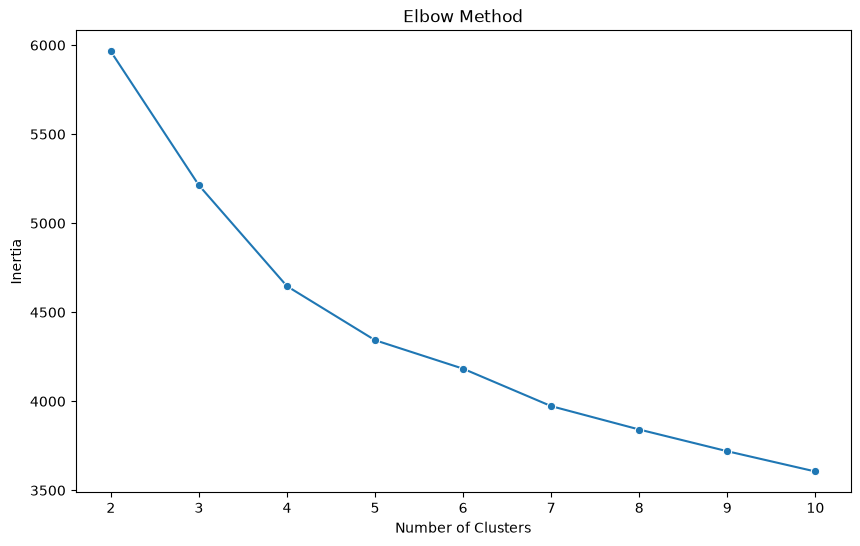

In [12]:
plt.figure(figsize=(10, 6))
sns.lineplot(x=k_range, y=silhouette_scores, marker='o')
plt.title('Silhouette Score vs. Number of Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.xticks(k_range)
plt.show()

# elbow method


plt.figure(figsize=(10, 6))
sns.lineplot(x=k_range, y=inertia, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.xticks(k_range)
plt.show()

Entraîner un modèle K-Means avec le nombre de clusters choisi.

In [13]:

kmeans_final = KMeans(n_clusters=best_k, random_state=42)



Ajouter une colonne Cluster au dataset indiquant le groupe assigné à chaque individu.

In [14]:
cluster_labels = kmeans_final.fit_predict(df_scaled)

df_scaled['Cluster'] = cluster_labels

df_cleaned['Cluster'] = cluster_labels

display(df_scaled)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Insulin_Glucose_Ratio,BMI-Category,Cluster
0,0.647150,0.866296,-0.030050,0.662965,0.272493,0.185339,0.588927,1.445691,-0.070595,0.705406,0
1,-0.848970,-1.200858,-0.538380,-0.001760,-1.127910,-0.863528,-0.378101,-0.189304,-1.004756,-0.687272,1
2,1.245598,2.014715,-0.707824,-0.356280,0.216680,-1.357994,0.746595,-0.103252,-0.571118,-2.079951,1
3,-0.848970,-1.069610,-0.538380,-0.666485,-0.678867,-0.638771,-1.022787,-1.049828,-0.247551,-0.687272,1
4,-1.148194,0.505364,-2.741146,0.662965,0.259809,1.608801,2.596563,-0.017199,0.103622,0.705406,0
...,...,...,...,...,...,...,...,...,...,...,...
763,1.844045,-0.675867,0.308837,2.103202,0.412026,0.080452,-1.008772,2.564372,1.251298,0.705406,0
764,-0.549746,0.013185,-0.199493,-0.223335,0.221754,0.664821,-0.416642,-0.533513,0.364128,0.705406,0
765,0.347926,-0.019627,-0.030050,-0.666485,-0.450541,-0.923463,-0.749497,-0.275356,-0.517096,-0.687272,1
766,-0.848970,0.144432,-1.046711,0.685122,-0.168938,-0.339095,-0.385109,1.187534,-0.229177,0.705406,0


Visualiser la répartition des observations par cluster et interpréter les résultats.

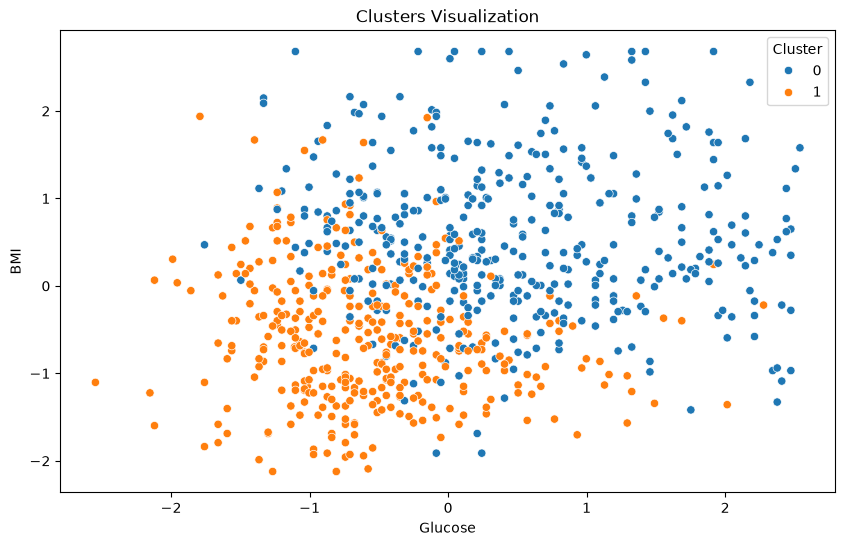

In [15]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_scaled, x='Glucose', y='BMI', hue='Cluster')
plt.title('Clusters Visualization')
plt.show()



## Étape 4 — Analyse des clusters

Calculer les moyennes des caractéristiques au sein de chaque cluster

In [16]:
cluster_summary = df_cleaned.copy()
cluster_summary["Cluster"] = cluster_labels
cluster_summary1 = cluster_summary.groupby("Cluster").mean()
display(cluster_summary1)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Insulin_Glucose_Ratio,BMI-Category
Cluster,,,,,,,,,,
0,4.656020,136.617199,76.790172,33.633907,192.059951,35.971646,0.503973,37.721130,1.407011,2.859951
1,2.914127,104.665374,67.354017,23.809418,97.300623,28.294681,0.408114,28.102493,0.915736,2.080332


Compter le nombre d’observations par groupe.

In [17]:
cluster_counts = df_scaled["Cluster"].value_counts()

print("Nombre d'observations par cluster :")
print(cluster_counts)

Nombre d'observations par cluster :
Cluster
0    407
1    361
Name: count, dtype: int64


Le cluster dont les moyennes des variables Glucose (>126), BMI (>30) et Diabetes Pedigree Function (>0,5) dépassent les seuils critiques peut être interprété comme à haut risque de diabète.

In [18]:
cluster_haut_risk = cluster_summary1[
    (cluster_summary1['Glucose'] > 126) & 
    (cluster_summary1['BMI'] > 30) &
    (cluster_summary1['DiabetesPedigreeFunction'] > 0.5)
]
list_clusters_haut_risk = cluster_haut_risk.index.tolist()
print("Clusters à haut risque identifiés :", list_clusters_haut_risk)




Clusters à haut risque identifiés : [0]


Ajouter une colonne risk_category basée sur le numero de cluster (ex. : si 1 => risque élevé et 0 => faible).

In [19]:
cluster_summary['risk_category'] = np.where(
    cluster_summary['Cluster'].isin(list_clusters_haut_risk),
    1, 
    0   
)

display(cluster_summary)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Insulin_Glucose_Ratio,BMI-Category,Cluster,risk_category
0,6.0,148.0,72.0,35.0,169.0,33.6,0.627,50.0,1.141892,3,0,1
1,1.0,85.0,66.0,29.0,58.6,26.6,0.351,31.0,0.689412,2,1,0
2,8.0,183.0,64.0,25.8,164.6,23.3,0.672,32.0,0.899454,1,1,0
3,1.0,89.0,66.0,23.0,94.0,28.1,0.167,21.0,1.056180,2,1,0
4,0.0,137.0,40.0,35.0,168.0,43.1,1.200,33.0,1.226277,3,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...
763,10.0,101.0,76.0,48.0,180.0,32.9,0.171,63.0,1.782178,3,0,1
764,2.0,122.0,70.0,27.0,165.0,36.8,0.340,27.0,1.352459,3,0,1
765,5.0,121.0,72.0,23.0,112.0,26.2,0.245,30.0,0.925620,2,1,0
766,1.0,126.0,60.0,35.2,134.2,30.1,0.349,47.0,1.065079,3,0,1


## Étape 5 — Classification supervisée et évaluation des modèles


Définir la variable cible y à partir de la colonne Cluster. Définir X à partir des variables sélectionnées.

In [20]:

y = cluster_summary['risk_category']
X = df_scaled.copy()
X = X.drop('Cluster', axis=1)

print("Shape of X (Features):", X.shape)
print("Shape of y (Target):", y.shape)
display(X.head())
display(y.head())

Shape of X (Features): (768, 10)
Shape of y (Target): (768,)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Insulin_Glucose_Ratio,BMI-Category
0,0.647150,0.866296,-0.030050,0.662965,0.272493,0.185339,0.588927,1.445691,-0.070595,0.705406
1,-0.848970,-1.200858,-0.538380,-0.001760,-1.127910,-0.863528,-0.378101,-0.189304,-1.004756,-0.687272
2,1.245598,2.014715,-0.707824,-0.356280,0.216680,-1.357994,0.746595,-0.103252,-0.571118,-2.079951
3,-0.848970,-1.069610,-0.538380,-0.666485,-0.678867,-0.638771,-1.022787,-1.049828,-0.247551,-0.687272
4,-1.148194,0.505364,-2.741146,0.662965,0.259809,1.608801,2.596563,-0.017199,0.103622,0.705406


0    1
1    0
2    0
3    0
4    1
Name: risk_category, dtype: int64

Diviser les données en ensemble d’entraînement et de test à l’aide de traintestsplit.

In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,random_state=42,test_size=0.2)


Gérer le déséquilibre des classes avec des techniques de sur-échantillonnage ou sous-échantillonnage (RandomOverSampler, UnderSampler via imblearn).

In [22]:
cluster_total = cluster_summary['risk_category'].value_counts()
high_risk_percent = (cluster_total.get(1, 0) / cluster_total.sum()) * 100
low_risk_percent = (cluster_total.get(0, 0) / cluster_total.sum()) * 100

check_balance = "balanced" if abs(high_risk_percent - low_risk_percent) <= 10 else "imbalanced"

print(f"High risk percentage: {high_risk_percent:.2f}%")
print(f"Low risk percentage: {low_risk_percent:.2f}%")

print(f"Dataset balance: {check_balance}")



High risk percentage: 52.99%
Low risk percentage: 47.01%
Dataset balance: balanced


Entraîner et comparer au minimum 3 modèles de classification en utilisant les mêmes données d’entraînement et de test .

In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

trained_models = {}

lg = LogisticRegression(random_state=42)
rf = RandomForestClassifier(random_state=42)
svc = SVC(random_state=42)

lg.fit(X_train, y_train)
rf.fit(X_train, y_train)
svc.fit(X_train, y_train)

trained_models['Logistic Regression'] = lg
trained_models['Random Forest'] = rf
trained_models['Support Vector Classifier'] = svc

print("Models trained successfully!")



Models trained successfully!


Utiliser des métriques appropriées à la classification telles que : matrice de confusion, précision, rappel, F1-score.

In [24]:
from sklearn.metrics import confusion_matrix

final_results = {}

for name,model in trained_models.items():
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    prec = cm[1, 1] / (cm[1, 1] + cm[0, 1])
    rec = cm[1, 1] / (cm[1, 1] + cm[1, 0])
    f1 = 2 * (prec * rec) / (prec + rec)

    
    final_results[name] = {
        'confusion_matrix': cm,
        'Precision': prec,
        'Recall': rec,
        'F1 Score': f1
    }


print("Final Results:")
for name, metrics in final_results.items():
    print(f"\n{name}:")
    print(f"Confusion Matrix: {metrics['confusion_matrix']}")
    print(f"Precision: {metrics['Precision']}")
    print(f"Recall: {metrics['Recall']}")
    print(f"F1 Score: {metrics['F1 Score']}")

Final Results:

Logistic Regression:
Confusion Matrix: [[65  0]
 [ 2 87]]
Precision: 1.0
Recall: 0.9775280898876404
F1 Score: 0.9886363636363636

Random Forest:
Confusion Matrix: [[60  5]
 [ 8 81]]
Precision: 0.9418604651162791
Recall: 0.9101123595505618
F1 Score: 0.9257142857142857

Support Vector Classifier:
Confusion Matrix: [[62  3]
 [ 5 84]]
Precision: 0.9655172413793104
Recall: 0.9438202247191011
F1 Score: 0.9545454545454545


testing the model logisticregression

In [25]:
new_patient_data = pd.DataFrame({
    'Pregnancies': [2],
    'Glucose': [100],       
    'BloodPressure': [85],
    'SkinThickness': [32],
    'Insulin': [200],
    'BMI': [15],            
    'DiabetesPedigreeFunction': [0.65],
    'Age': [42],
    'Insulin_Glucose_Ratio': [1.03], 
    'BMI-Category': [3]      
})

new_patient_scaled = scaler.transform(new_patient_data)

prediction = lg.predict(new_patient_scaled)

if prediction[0] == 1:
    print("HIGH RISK")
else:
    print("LOW RISK")

HIGH RISK


c:\Users\medga\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2830: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


Utiliser des techniques comme GridSearchCV ou RandomizedSearchCV pour affiner les hyperparamètres des modèles et améliorer leurs performances.
Comparer les performances des différents modèles.
Choisir le modèle le plus performant.


In [36]:


from sklearn.model_selection import RandomizedSearchCV
import warnings
warnings.filterwarnings('ignore')

param_grid_lg = {
    'C': [0.01, 0.05, 0.1, 0.5, 1, 5, 10, 50, 100],
    'penalty': ['l1', 'l2'],
    'max_iter': [100, 200, 300]
}  
param_grid_rf = {
    'n_estimators': [25,50, 75, 100, 150, 200, 250, 300],
    'max_depth': [None, 10, 15, 20, 25, 30],
    'min_samples_split': [2, 3, 5, 7, 10],
    'min_samples_leaf': [1, 2, 4, 6, 8],
}
param_grid_svc = {
    'C': [0.01, 0.05, 0.1, 0.5, 1, 5, 10, 50, 100],
    'kernel': ['linear', 'poly', 'rbf', 'sigmoid'],
    'degree': [2, 3, 4]
}

random_search_lg = RandomizedSearchCV(estimator=lg, n_iter=20, param_distributions=param_grid_lg, cv=5, random_state=42)
random_search_rf = RandomizedSearchCV(estimator=rf, n_iter=20, param_distributions=param_grid_rf, cv=5, random_state=42)
random_search_svc = RandomizedSearchCV(estimator=svc, n_iter=20, param_distributions=param_grid_svc, cv=5, random_state=42)

random_search_lg.fit(X_train, y_train)
random_search_rf.fit(X_train, y_train)
random_search_svc.fit(X_train, y_train)

y_pred_optimized = random_search_lg.predict(X_test)
y_pred_optimized_rf = random_search_rf.predict(X_test)
y_pred_optimized_svc = random_search_svc.predict(X_test)


cm = confusion_matrix(y_test, y_pred_optimized)
prec = cm[1, 1] / (cm[1, 1] + cm[0, 1])
rec = cm[1, 1] / (cm[1, 1] + cm[1, 0])
f1 = 2 * (prec * rec) / (prec + rec)

cm_rf = confusion_matrix(y_test, y_pred_optimized_rf)
prec_rf = cm_rf[1, 1] / (cm_rf[1, 1] + cm_rf[0, 1])
rec_rf = cm_rf[1, 1] / (cm_rf[1, 1] + cm_rf[1, 0])
f1_rf = 2 * (prec_rf * rec_rf) / (prec_rf + rec_rf)

cm_svc = confusion_matrix(y_test, y_pred_optimized_svc)
prec_svc = cm_svc[1, 1] / (cm_svc[1, 1] + cm_svc[0, 1])
rec_svc = cm_svc[1, 1] / (cm_svc[1, 1] + cm_svc[1, 0])
f1_svc = 2 * (prec_svc * rec_svc) / (prec_svc + rec_svc)


    
final_results['logistic_regression best parameters'] = {
    'confusion_matrix': cm,
    'Precision': prec,
    'Recall': rec,
    'F1 Score': f1
}

final_results['random_forest best parameters'] = {
    'confusion_matrix': cm_rf,
    'Precision': prec_rf,
    'Recall': rec_rf,
    'F1 Score': f1_rf
}

final_results['support_vector_machine best parameters'] = {
    'confusion_matrix': cm_svc,
    'Precision': prec_svc,
    'Recall': rec_svc,
    'F1 Score': f1_svc
}

best_model = final_results['logistic_regression best parameters']['F1 Score'] >= final_results['random_forest best parameters']['F1 Score'] and final_results['logistic_regression best parameters']['F1 Score'] >= final_results['support_vector_machine best parameters']['F1 Score']
if best_model:  
    best_model = 'logistic_regression best parameters'
elif final_results['random_forest best parameters']['F1 Score'] >= final_results['support_vector_machine best parameters']['F1 Score']:
    best_model = 'random_forest best parameters'
else:
    best_model = 'support_vector_machine best parameters'

print(f"The best model is: {best_model} with F1 Score: {final_results[best_model]['F1 Score']:.4f}")





The best model is: logistic_regression best parameters with F1 Score: 0.9886


Construire un Pipeline intégrant le prétraitement des données et le modèle final, puis sauvegarder l’ensemble dans un fichier (.pkl ou .joblib).

In [38]:
import joblib

best_lr_model = random_search_lg.best_estimator_

joblib.dump(scaler, '../models/scaler.pkl')
joblib.dump(best_lr_model, '../models/logistic_regression_model.pkl')


['../models/logistic_regression_model.pkl']